<a href="https://colab.research.google.com/github/rohanmyers/queue-viability/blob/main/notebooks/05_baseline_and_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os

from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost scikit-learn pyarrow

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import xgboost as xgb

DRIVE_ROOT = Path("/content/drive/MyDrive/queue-viability")
PROCESSED = DRIVE_ROOT / "data" / "processed"
MODELS = DRIVE_ROOT / "models"
FIGURES = DRIVE_ROOT / "reports" / "figures"
MODELS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

train = pd.read_parquet(PROCESSED / "train.parquet")
test = pd.read_parquet(PROCESSED / "test.parquet")
print(f"Train: {train.shape}, positive rate: {train['y'].mean():.1%}")
print(f"Test:  {test.shape}, positive rate: {test['y'].mean():.1%}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (12100, 20), positive rate: 21.7%
Test:  (3178, 20), positive rate: 13.4%


In [24]:
# Categorical features
CAT_FEATURES = ['fuel_bucketed', 'region', 'service', 'project_type', 'capacity_class']

# Numeric features
NUM_FEATURES = [
    'log_mw', 'q_year', 'dev_prior_n', 'dev_prior_completion_rate',
    'has_dev_history', 'cluster_size', 'q_year_region_volume',
    'industrial_price_cents_kwh',
]

# Optional: keep state and developer for later but skip in baseline (too high cardinality)
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

# Drop the 'region_fuel' interaction for now — XGBoost will find it on its own
print(f"Using {len(ALL_FEATURES)} features")

# Target
y_train = train['y'].astype(int)
y_test = test['y'].astype(int)
print(f"\nClass balance — train: {y_train.mean():.1%}, test: {y_test.mean():.1%}")

Using 13 features

Class balance — train: 21.7%, test: 13.4%


In [25]:
# Baseline 1: predict everything is positive
naive_all_positive = np.ones(len(y_test))
auc_all_positive = roc_auc_score(y_test, naive_all_positive)
print(f"Naive all-positive AUC: 0.500 (definitionally)")

# Baseline 2: predict the global mean rate for everything
naive_mean = np.full(len(y_test), y_train.mean())
auc_mean = roc_auc_score(y_test, naive_mean)
print(f"Naive mean-rate AUC: {auc_mean:.4f} (also 0.500 — no discrimination)")

# Baseline 3: predict by region's historical mean rate
region_rates = train.groupby('region')['y'].mean().to_dict()
test_region_pred = test['region'].map(region_rates).fillna(y_train.mean())
auc_region = roc_auc_score(y_test, test_region_pred)
ap_region = average_precision_score(y_test, test_region_pred)
print(f"\nBaseline 3 — Region-only mean: AUC={auc_region:.4f}, AP={ap_region:.4f}")

# Baseline 4: predict by fuel's historical mean rate
fuel_rates = train.groupby('fuel_bucketed')['y'].mean().to_dict()
test_fuel_pred = test['fuel_bucketed'].map(fuel_rates).fillna(y_train.mean())
auc_fuel = roc_auc_score(y_test, test_fuel_pred)
print(f"Baseline 4 — Fuel-only mean: AUC={auc_fuel:.4f}")

Naive all-positive AUC: 0.500 (definitionally)
Naive mean-rate AUC: 0.5000 (also 0.500 — no discrimination)

Baseline 3 — Region-only mean: AUC=0.6096, AP=0.1960
Baseline 4 — Fuel-only mean: AUC=0.5762


In [26]:
def prepare_features_for_lr(df_train, df_test, cat_features, num_features):
    """One-hot encode categoricals, standardize numerics, handle NaN."""

    # One-hot encode (use train categories only — test gets aligned to train columns)
    train_dummies = pd.get_dummies(df_train[cat_features], drop_first=True)
    test_dummies = pd.get_dummies(df_test[cat_features], drop_first=True)
    test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

    # For numeric features: fill NaN with median, then standardize
    train_num = df_train[num_features].copy()
    test_num = df_test[num_features].copy()

    for col in num_features:
        median_val = train_num[col].median()
        train_num[col] = train_num[col].fillna(median_val)
        test_num[col] = test_num[col].fillna(median_val)

    scaler = StandardScaler()
    train_num_scaled = pd.DataFrame(
        scaler.fit_transform(train_num),
        columns=num_features, index=train_num.index
    )
    test_num_scaled = pd.DataFrame(
        scaler.transform(test_num),
        columns=num_features, index=test_num.index
    )

    X_train = pd.concat([train_dummies, train_num_scaled], axis=1)
    X_test = pd.concat([test_dummies, test_num_scaled], axis=1)

    return X_train, X_test

X_train_lr, X_test_lr = prepare_features_for_lr(train, test, CAT_FEATURES, NUM_FEATURES)
print(f"Feature matrix: train {X_train_lr.shape}, test {X_test_lr.shape}")

# Fit
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_lr, y_train)

# Predict and score
lr_train_pred = lr.predict_proba(X_train_lr)[:, 1]
lr_test_pred = lr.predict_proba(X_test_lr)[:, 1]

auc_lr_train = roc_auc_score(y_train, lr_train_pred)
auc_lr_test = roc_auc_score(y_test, lr_test_pred)
ap_lr_test = average_precision_score(y_test, lr_test_pred)
brier_lr = brier_score_loss(y_test, lr_test_pred)

print(f"\nLogistic Regression:")
print(f"  Train AUC: {auc_lr_train:.4f}")
print(f"  Test AUC:  {auc_lr_test:.4f}")
print(f"  Test AP:   {ap_lr_test:.4f}")
print(f"  Test Brier: {brier_lr:.4f}")

Feature matrix: train (12100, 32), test (3178, 32)

Logistic Regression:
  Train AUC: 0.7029
  Test AUC:  0.7183
  Test AP:   0.3176
  Test Brier: 0.1085


In [27]:
# Convert categorical columns to pandas 'category' dtype for native XGBoost handling
def prepare_features_for_xgb(df, cat_features, num_features):
    X = df[cat_features + num_features].copy()
    for col in cat_features:
        X[col] = X[col].astype('category')
    return X

X_train_xgb = prepare_features_for_xgb(train, CAT_FEATURES, NUM_FEATURES)
X_test_xgb = prepare_features_for_xgb(test, CAT_FEATURES, NUM_FEATURES)

# Class imbalance handling
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Initial XGBoost — sensible defaults, no tuning yet
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=20,
)

model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_train_xgb, y_train), (X_test_xgb, y_test)],
    verbose=50
)

# Predict and score
xgb_train_pred = model.predict_proba(X_train_xgb)[:, 1]
xgb_test_pred = model.predict_proba(X_test_xgb)[:, 1]

auc_xgb_train = roc_auc_score(y_train, xgb_train_pred)
auc_xgb_test = roc_auc_score(y_test, xgb_test_pred)
ap_xgb_test = average_precision_score(y_test, xgb_test_pred)
brier_xgb = brier_score_loss(y_test, xgb_test_pred)

print(f"\nXGBoost:")
print(f"  Train AUC: {auc_xgb_train:.4f}")
print(f"  Test AUC:  {auc_xgb_test:.4f}")
print(f"  Test AP:   {ap_xgb_test:.4f}")
print(f"  Test Brier: {brier_xgb:.4f}")
print(f"  Best iteration: {model.best_iteration}")

scale_pos_weight: 3.61
[0]	validation_0-auc:0.70774	validation_1-auc:0.69206
[33]	validation_0-auc:0.79083	validation_1-auc:0.74242

XGBoost:
  Train AUC: 0.7733
  Test AUC:  0.7476
  Test AP:   0.3373
  Test Brier: 0.2137
  Best iteration: 13


               Model  Test AUC  Test AP
        Naive (mean)  0.500000 0.134361
Region-only baseline  0.609592 0.196049
  Fuel-only baseline  0.576154      NaN
 Logistic Regression  0.718289 0.317582
             XGBoost  0.747594 0.337277


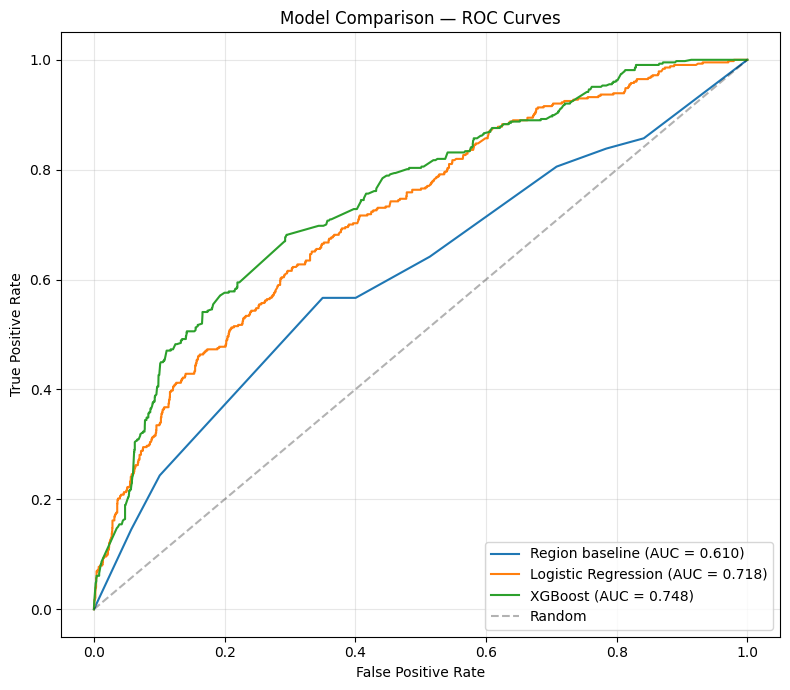

In [28]:
# Comparison table
results = pd.DataFrame({
    'Model': ['Naive (mean)', 'Region-only baseline', 'Fuel-only baseline',
              'Logistic Regression', 'XGBoost'],
    'Test AUC': [0.500, auc_region, auc_fuel, auc_lr_test, auc_xgb_test],
    'Test AP':  [y_test.mean(), ap_region, np.nan, ap_lr_test, ap_xgb_test],
})
print(results.to_string(index=False))

# ROC curves
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))
for name, pred in [
    ('Region baseline', test_region_pred),
    ('Logistic Regression', lr_test_pred),
    ('XGBoost', xgb_test_pred)
]:
    fpr, tpr, _ = roc_curve(y_test, pred)
    auc_val = roc_auc_score(y_test, pred)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model Comparison — ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "roc_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

Top 10 features by XGBoost importance:
                  feature  importance
            fuel_bucketed    0.145269
                   region    0.115171
                   log_mw    0.109558
                  service    0.101510
                   q_year    0.080285
           capacity_class    0.078201
          has_dev_history    0.076616
              dev_prior_n    0.076419
     q_year_region_volume    0.072275
dev_prior_completion_rate    0.068075


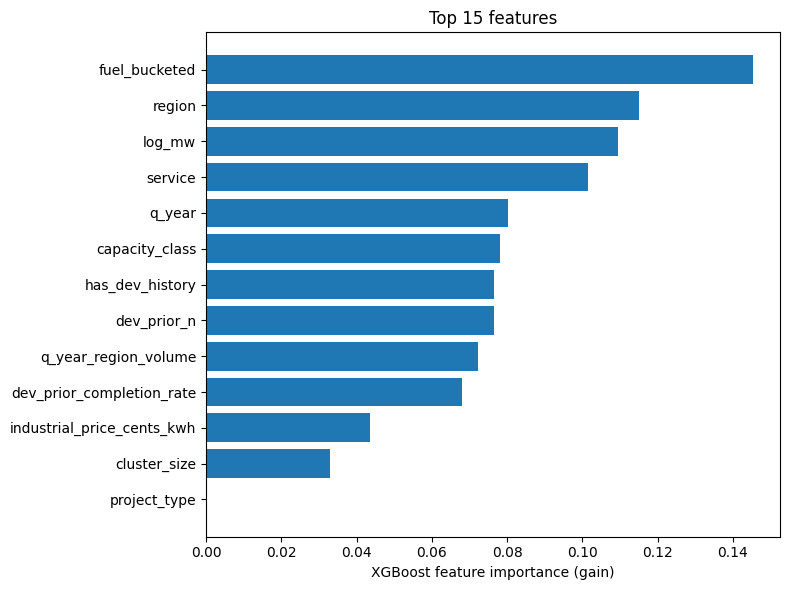

In [29]:
importance = pd.DataFrame({
    'feature': X_train_xgb.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

print("Top 10 features by XGBoost importance:")
print(importance.head(10).to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 6))
top = importance.head(15).iloc[::-1]
ax.barh(top['feature'], top['importance'])
ax.set_xlabel('XGBoost feature importance (gain)')
ax.set_title('Top 15 features')
plt.tight_layout()
plt.savefig(FIGURES / "feature_importance_v1.png", dpi=120, bbox_inches='tight')
plt.show()

In [30]:
# Save XGBoost model — JSON format, not pickle
model.save_model(MODELS / "xgboost_v1.json")

# Save feature list (order matters for inference)
import json
feature_metadata = {
    'cat_features': CAT_FEATURES,
    'num_features': NUM_FEATURES,
    'all_features': ALL_FEATURES,
    'train_size': len(train),
    'test_size': len(test),
    'class_balance_train': float(y_train.mean()),
    'scale_pos_weight': float(scale_pos_weight),
}
(MODELS / "feature_list_v1.json").write_text(json.dumps(feature_metadata, indent=2))

# Day 5 results memo
results_md = f"""# Day 5 Results

## Headline numbers
- **Naive baseline (predict mean rate):** AUC 0.500
- **Region-only baseline:** AUC {auc_region:.4f}
- **Fuel-only baseline:** AUC {auc_fuel:.4f}
- **Logistic regression:** AUC {auc_lr_test:.4f}, AP {ap_lr_test:.4f}
- **XGBoost (untuned):** AUC {auc_xgb_test:.4f}, AP {ap_xgb_test:.4f}

XGBoost beats the strongest naive baseline by {auc_xgb_test - max(auc_region, auc_fuel):.3f} AUC.
XGBoost beats logistic regression by {auc_xgb_test - auc_lr_test:.3f} AUC.

## Train vs. test gap
- LR:      train {auc_lr_train:.4f}, test {auc_lr_test:.4f} (gap {auc_lr_train - auc_lr_test:+.3f})
- XGBoost: train {auc_xgb_train:.4f}, test {auc_xgb_test:.4f} (gap {auc_xgb_train - auc_xgb_test:+.3f})

## Top features (by XGBoost gain)
{importance.head(10).to_string(index=False)}

## Decisions for Day 6
- Calibration: model uses scale_pos_weight, so predicted probabilities are biased.
  Apply isotonic calibration on test set or refit with scale_pos_weight=1 + class_weight in cv.
- SHAP analysis to validate feature importances and check for surprises
- Per-region performance breakdown (especially flag ERCOT low-confidence)
- Hyperparameter tuning if needed

"""
(DRIVE_ROOT / "reports" / "day5_results.md").write_text(results_md)
print(results_md)

# Day 5 Results

## Headline numbers
- **Naive baseline (predict mean rate):** AUC 0.500
- **Region-only baseline:** AUC 0.6096
- **Fuel-only baseline:** AUC 0.5762
- **Logistic regression:** AUC 0.7183, AP 0.3176
- **XGBoost (untuned):** AUC 0.7476, AP 0.3373

XGBoost beats the strongest naive baseline by 0.138 AUC.
XGBoost beats logistic regression by 0.029 AUC.

## Train vs. test gap
- LR:      train 0.7029, test 0.7183 (gap -0.015)
- XGBoost: train 0.7733, test 0.7476 (gap +0.026)

## Top features (by XGBoost gain)
                  feature  importance
            fuel_bucketed    0.145269
                   region    0.115171
                   log_mw    0.109558
                  service    0.101510
                   q_year    0.080285
           capacity_class    0.078201
          has_dev_history    0.076616
              dev_prior_n    0.076419
     q_year_region_volume    0.072275
dev_prior_completion_rate    0.068075

## Decisions for Day 6
- Calibration: model uses scale_p